# Fractional Ornstein-Uhlenbeck Process

## 1. Definition

The **standard Ornstein-Uhlenbeck (OU)** process solves:
$$dX_t = -\theta X_t\,dt + \sigma\,dW_t$$

The **fractional OU** replaces Brownian motion $W_t$ with **fractional Brownian motion** $B_H(t)$:

$$\boxed{dX_t = -\theta X_t\,dt + \sigma\,dB_H(t)}$$

with solution (formal):
$$X_t = x_0 e^{-\theta t} + \sigma\int_0^t e^{-\theta(t-s)}\,dB_H(s)$$

**Parameters:**
- $\theta > 0$: mean-reversion speed
- $\sigma > 0$: volatility
- $H \in (0,1)$: Hurst exponent
- $x_0$: initial value

## 2. Key Properties

| Feature | Standard OU ($H=0.5$) | Fractional OU ($H \neq 0.5$) |
|---------|----------------------|------------------------------|
| **Noise** | Markovian | Non-Markovian (long memory for $H>0.5$) |
| **Stationary distribution** | Gaussian | Gaussian |
| **Autocorrelation** | Exponential decay | Power-law decay (long-range dependence) |
| **Path regularity** | $1/2$-Hölder | $H$-Hölder |

For $H > 0.5$, the fOU process exhibits **persistence**: shocks decay slowly and the process "remembers" its history. For $H < 0.5$, it is **anti-persistent**.

## 3. Simulation: Euler-Maruyama Scheme

Since $B_H(t)$ is generated exactly via Cholesky, the Euler scheme is:

$$X_{n+1} = X_n - \theta X_n \Delta t + \sigma\,(B_H(t_{n+1}) - B_H(t_n))$$

For $H=0.5$, the increment variance is $\Delta t$, recovering standard Euler-Maruyama.


In [3]:
# Cell 1: Imports and Setup
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cholesky
import os

np.random.seed(42)

SAVE_DIR = './fou_output'
os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10


In [4]:
# Cell 2: Core Functions — fBm and fOU

def fbm_covariance(t, H):
    """Covariance matrix of fractional Brownian motion."""
    t = np.asarray(t)
    s = t[:, np.newaxis]
    t_row = t[np.newaxis, :]
    return 0.5 * (s**(2*H) + t_row**(2*H) - np.abs(s - t_row)**(2*H))


def generate_fbm(t, H):
    """Generate one fBm path via Cholesky decomposition."""
    n = len(t)
    C = fbm_covariance(t, H)
    L = cholesky(C + 1e-12 * np.eye(n), lower=True)
    z = np.random.randn(n)
    return L @ z


def simulate_fou(t, H, theta, sigma, x0=0.0):
    """
    Simulate fOU via Euler-Maruyama with a shared fBm path.
    dX_t = -theta * X_t dt + sigma * dB_H(t)
    """
    n = len(t)
    dt = np.diff(t)
    B = generate_fbm(t, H)
    dB = np.diff(B)
    
    X = np.zeros(n)
    X[0] = x0
    
    for i in range(n - 1):
        X[i + 1] = X[i] - theta * X[i] * dt[i] + sigma * dB[i]
    
    return X


def simulate_fou_multi(t, H, theta, sigma, x0_list):
    """
    Simulate multiple fOU paths driven by the *same* fBm noise.
    Useful for demonstrating deterministic mean-reversion of differences.
    """
    n = len(t)
    dt = np.diff(t)
    B = generate_fbm(t, H)
    dB = np.diff(B)
    
    n_paths = len(x0_list)
    X = np.zeros((n_paths, n))
    X[:, 0] = x0_list
    
    for i in range(n - 1):
        X[:, i + 1] = X[:, i] - theta * X[:, i] * dt[i] + sigma * dB[i]
    
    return X


def estimate_acf(x, max_lag):
    """Estimate autocorrelation function (biased estimator, stable)."""
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    n = len(x)
    c0 = np.dot(x, x) / n
    acf = np.zeros(max_lag)
    for lag in range(max_lag):
        if lag == 0:
            acf[lag] = 1.0
        else:
            acf[lag] = np.dot(x[:-lag], x[lag:]) / n / c0
    return acf


In [5]:
# Cell A: ADD THESE OPTIMIZED FUNCTIONS (run once after Cell 2)

def generate_fbm_multi(t, H, n_paths):
    """
    Generate n_paths independent fBm realizations with a SINGLE Cholesky.
    Returns array of shape (n_times, n_paths).
    """
    n = len(t)
    C = fbm_covariance(t, H)
    L = cholesky(C + 1e-12 * np.eye(n), lower=True)
    Z = np.random.randn(n, n_paths)
    return L @ Z


def simulate_fou_multi_independent(t, H, theta, sigma, x0, n_paths):
    """
    Simulate n_paths independent fOU paths.
    Only ONE Cholesky decomposition is performed.
    """
    B = generate_fbm_multi(t, H, n_paths)   # (n_times, n_paths)
    dt = np.diff(t)[:, None]                # (n_times-1, 1)
    dB = np.diff(B, axis=0)                 # (n_times-1, n_paths)
    
    n = len(t)
    X = np.zeros((n, n_paths))
    X[0, :] = x0 if np.isscalar(x0) else np.asarray(x0)
    
    for i in range(n - 1):
        X[i + 1, :] = X[i, :] - theta * X[i, :] * dt[i, 0] + sigma * dB[i, :]
    
    return X


def estimate_acf_fast(x, max_lag):
    """FFT-based autocorrelation (much faster for long series)."""
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    n = len(x)
    nfft = 1 << (2 * n - 1).bit_length()
    xf = np.fft.rfft(x, n=nfft)
    acf = np.fft.irfft(xf * xf.conj())[:n] / n
    c0 = acf[0]
    if c0 == 0:
        return np.zeros(max_lag)
    return acf[:max_lag] / c0


## 4. Sample Paths: Effect of Hurst Exponent

We fix $\theta = 2.0$, $\sigma = 1.0$ and vary $H$. Notice how $H > 0.5$ produces smoother, more persistent paths, while $H < 0.5$ looks rougher.


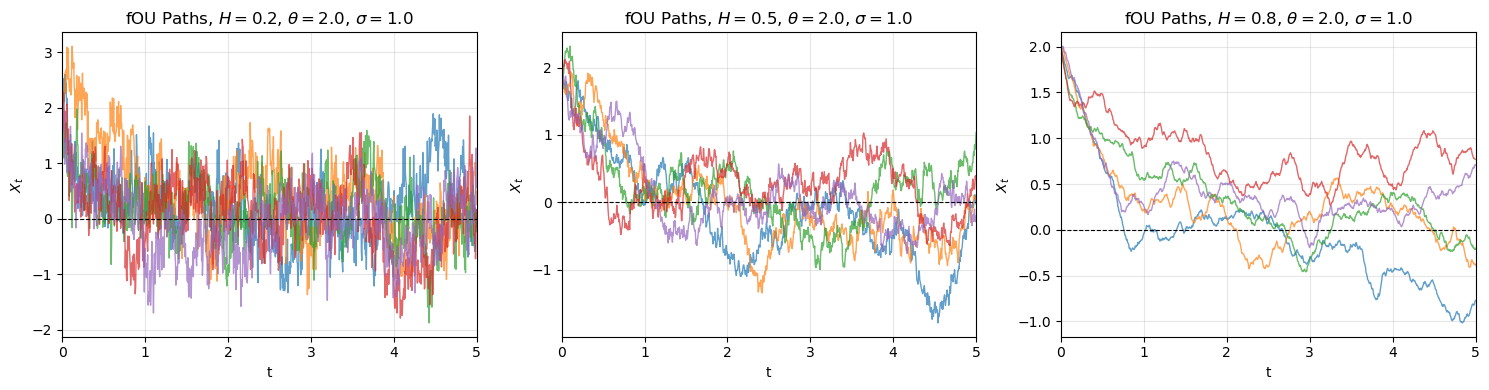

In [6]:
# Cell 3: Sample Paths for Different H

n = 1000
T = 5.0
t = np.linspace(0, T, n)
H_values = [0.2, 0.5, 0.8]
theta = 2.0
sigma = 1.0
n_paths = 5

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, H in enumerate(H_values):
    ax = axes[idx]
    for _ in range(n_paths):
        X = simulate_fou(t, H, theta, sigma, x0=2.0)
        ax.plot(t, X, alpha=0.7, linewidth=1.0)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(rf'fOU Paths, $H = {H}$, $\theta = {theta}$, $\sigma = {sigma}$')
    ax.set_xlabel('t')
    ax.set_ylabel(r'$X_t$')
    ax.set_xlim(0, T)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fou_sample_paths.png'), dpi=150, bbox_inches='tight')
plt.show()


## 5. Mean Reversion: Same Noise, Different Initial Conditions

Because the SDE is linear, the difference between two solutions driven by identical noise decays deterministically:
$$X_t^{(1)} - X_t^{(2)} = (x_0^{(1)} - x_0^{(2)})\,e^{-\theta t}$$

This is a striking visual demonstration of mean reversion.


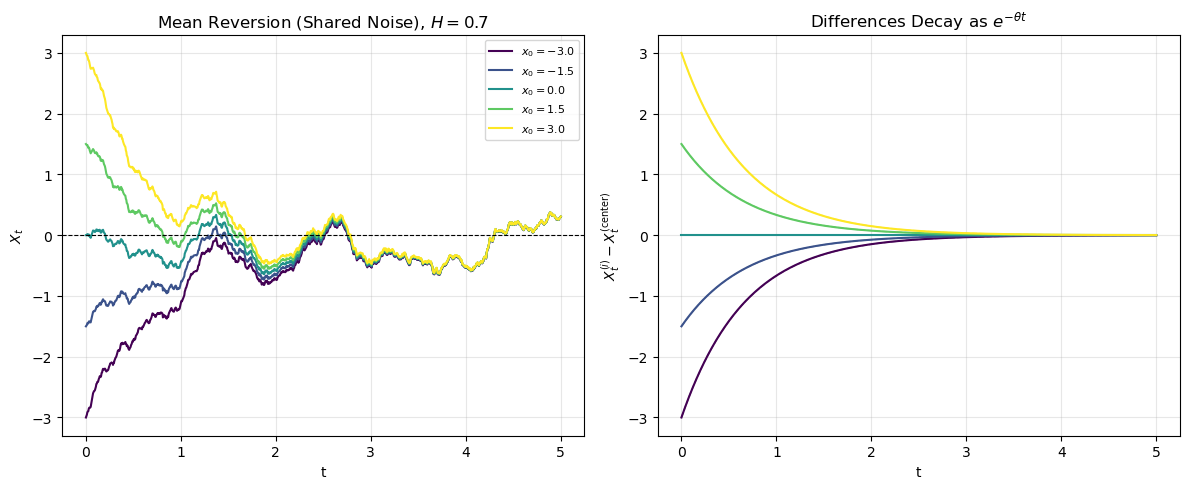

In [7]:
# Cell 4: Mean Reversion with Shared Noise

x0_list = np.array([-3.0, -1.5, 0.0, 1.5, 3.0])
H = 0.7
theta = 1.5
sigma = 0.8

X_multi = simulate_fou_multi(t, H, theta, sigma, x0_list)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: paths
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 1, len(x0_list)))
for i, x0 in enumerate(x0_list):
    ax.plot(t, X_multi[i], color=colors[i], linewidth=1.5, label=rf'$x_0 = {x0}$')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(rf'Mean Reversion (Shared Noise), $H = {H}$')
ax.set_xlabel('t')
ax.set_ylabel(r'$X_t$')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

# Right: differences from center path
ax = axes[1]
center = X_multi[len(x0_list)//2]
for i, x0 in enumerate(x0_list):
    diff = X_multi[i] - center
    ax.plot(t, diff, color=colors[i], linewidth=1.5, label=rf'$\Delta x_0 = {x0 - x0_list[len(x0_list)//2]}$')
    
    # Theoretical deterministic decay
    if i != len(x0_list)//2:
        theory = (x0 - x0_list[len(x0_list)//2]) * np.exp(-theta * t)
        ax.plot(t, theory, '--', color=colors[i], linewidth=1.0, alpha=0.6)

ax.set_title(rf'Differences Decay as $e^{{-\theta t}}$')
ax.set_xlabel('t')
ax.set_ylabel(r'$X_t^{{(i)}} - X_t^{{(\mathrm{{center}})}}$')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fou_mean_reversion.png'), dpi=150, bbox_inches='tight')
plt.show()


## 6. Stationary Distribution

For large $t$, the fOU process approaches a stationary Gaussian distribution. We simulate long paths and examine the histogram of $X_t$ values in the stationary regime.


In [ ]:
# Cell 5: Stationary Distribution, takes too much time

T_long = 50.0
n_long = 5000
t_long = np.linspace(0, T_long, n_long)
burn_in = 1000  # Discard transient

H_values = [0.3, 0.5, 0.7]
theta = 1.0
sigma = 1.0
n_sims = 500

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, H in enumerate(H_values):
    samples = []
    for _ in range(n_sims):
        X = simulate_fou(t_long, H, theta, sigma, x0=0.0)
        samples.extend(X[burn_in:].tolist())
    
    ax = axes[idx]
    ax.hist(samples, bins=60, density=True, alpha=0.7, color='tab:blue', edgecolor='white')
    
    # Fit Gaussian
    mu_est = np.mean(samples)
    std_est = np.std(samples)
    x_grid = np.linspace(min(samples), max(samples), 300)
    pdf = (1 / (std_est * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_grid - mu_est) / std_est)**2)
    ax.plot(x_grid, pdf, 'r-', linewidth=2, label='Gaussian fit')
    
    ax.set_title(rf'Stationary Dist, $H = {H}$' + '\n' + rf'$\mu = {mu_est:.3f}$, $\sigma_{{\mathrm{{stat}}}} = {std_est:.3f}$')
    ax.set_xlabel(r'$X_t$')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fou_stationary_dist.png'), dpi=150, bbox_inches='tight')
plt.show()


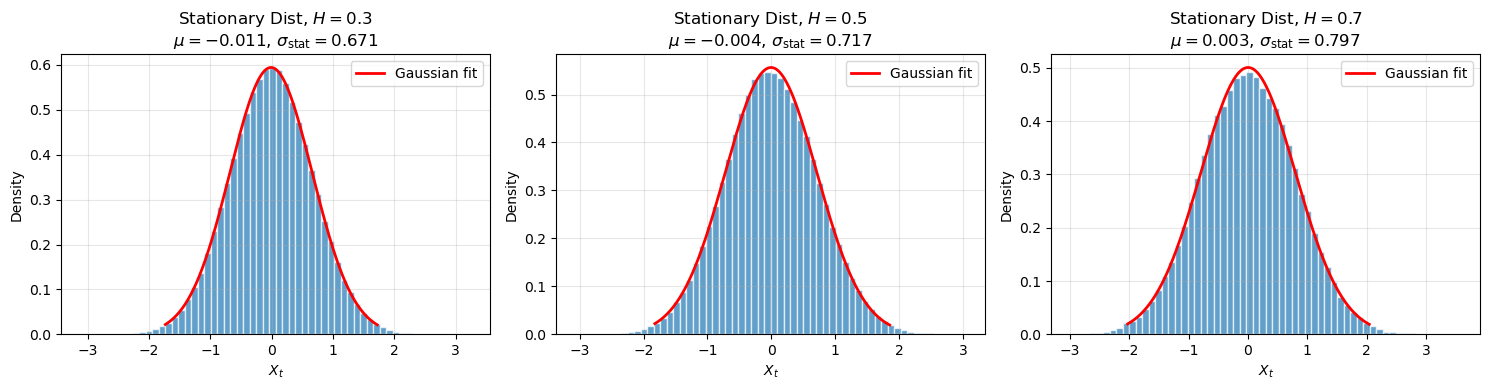

In [8]:
# Cell 5 (OPTIMIZED): Stationary Distribution

T_long = 20.0      # Reduced from 50; still plenty for stationarity
n_long = 2000      # Reduced from 5000
t_long = np.linspace(0, T_long, n_long)
burn_in = 500      # Discard first 25% as transient
H_values = [0.3, 0.5, 0.7]
theta = 1.0
sigma = 1.0
n_sims = 500

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, H in enumerate(H_values):
    # ONE Cholesky for all 500 paths — this is the game changer
    X_all = simulate_fou_multi_independent(t_long, H, theta, sigma, 0.0, n_sims)
    samples = X_all[burn_in:, :].flatten()
    
    ax = axes[idx]
    ax.hist(samples, bins=60, density=True, alpha=0.7, color='tab:blue', edgecolor='white')
    
    mu_est = np.mean(samples)
    std_est = np.std(samples)
    x_grid = np.linspace(np.percentile(samples, 0.5), np.percentile(samples, 99.5), 300)
    pdf = (1 / (std_est * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_grid - mu_est) / std_est)**2)
    ax.plot(x_grid, pdf, 'r-', linewidth=2, label='Gaussian fit')
    
    ax.set_title(rf'Stationary Dist, $H = {H}$' + '\n' + rf'$\mu = {mu_est:.3f}$, $\sigma_{{\mathrm{{stat}}}} = {std_est:.3f}$')
    ax.set_xlabel(r'$X_t$')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fou_stationary_dist.png'), dpi=150, bbox_inches='tight')
plt.show()


## 7. Autocorrelation Structure

The autocorrelation function (ACF) reveals the memory properties:

- **$H = 0.5$**: Exponential decay (Markovian)
- **$H > 0.5$**: Slower, power-law decay (long memory)
- **$H < 0.5$**: Rapid oscillatory decay (anti-persistence)

We estimate the ACF by averaging over many independent paths to reduce noise.


In [ ]:
# Cell 6: Autocorrelation Comparison,takes too much time

H_values = [0.3, 0.5, 0.8]
theta = 1.0
sigma = 1.0
n_sims_acf = 200
max_lag = 150

fig, ax = plt.subplots(figsize=(10, 6))

for H in H_values:
    acf_avg = np.zeros(max_lag)
    for _ in range(n_sims_acf):
        X = simulate_fou(t_long, H, theta, sigma, x0=0.0)
        acf_avg += estimate_acf(X[burn_in:], max_lag)
    acf_avg /= n_sims_acf
    
    ax.plot(np.arange(max_lag), acf_avg, linewidth=2, label=rf'$H = {H}$')

# Theoretical exponential for H=0.5
lags = np.arange(max_lag)
theo_ou = np.exp(-theta * lags * (t_long[1] - t_long[0]))
ax.plot(lags, theo_ou, 'k--', linewidth=1.5, alpha=0.6, label=rf'Theory OU ($e^{{-\theta \Delta t \cdot k}}$)')

ax.set_title('Autocorrelation Function of fOU')
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_xlim(0, max_lag)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fou_acf.png'), dpi=150, bbox_inches='tight')
plt.show()

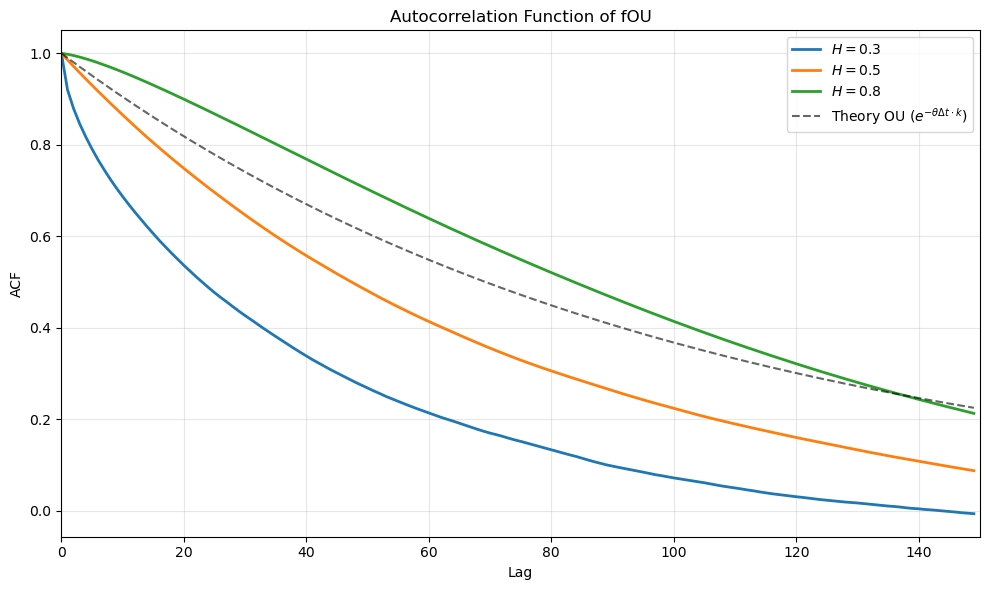

In [9]:
# Cell 6 (OPTIMIZED): Autocorrelation

H_values = [0.3, 0.5, 0.8]
theta = 1.0
sigma = 1.0
n_sims_acf = 200
max_lag = 150

fig, ax = plt.subplots(figsize=(10, 6))

for H in H_values:
    # Generate all 200 paths with one Cholesky
    X_all = simulate_fou_multi_independent(t_long, H, theta, sigma, 0.0, n_sims_acf)
    
    acf_all = np.zeros((n_sims_acf, max_lag))
    for i in range(n_sims_acf):
        acf_all[i, :] = estimate_acf_fast(X_all[burn_in:, i], max_lag)
    acf_avg = np.mean(acf_all, axis=0)
    
    ax.plot(np.arange(max_lag), acf_avg, linewidth=2, label=rf'$H = {H}$')

lags = np.arange(max_lag)
theo_ou = np.exp(-theta * lags * (t_long[1] - t_long[0]))
ax.plot(lags, theo_ou, 'k--', linewidth=1.5, alpha=0.6, label=rf'Theory OU ($e^{{-\theta \Delta t \cdot k}}$)')

ax.set_title('Autocorrelation Function of fOU')
ax.set_xlabel('Lag')
ax.set_ylabel('ACF')
ax.set_xlim(0, max_lag)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fou_acf.png'), dpi=150, bbox_inches='tight')
plt.show()


## 8. Parameter Sensitivity

### Effect of Mean-Reversion Speed $\theta$

Higher $\theta$ pulls the process to zero faster, reducing stationary variance and shortening memory.


In [ ]:
# Cell 7: Sensitivity to Theta, takes too much time

H = 0.7
sigma = 1.0
theta_values = [0.5, 1.5, 3.0]
n_paths = 5

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: sample paths
ax = axes[0]
colors = ['tab:blue', 'tab:orange', 'tab:green']
for theta, color in zip(theta_values, colors):
    for _ in range(n_paths):
        X = simulate_fou(t, H, theta, sigma, x0=2.0)
        ax.plot(t, X, color=color, alpha=0.5, linewidth=1.0)
    ax.plot([], [], color=color, linewidth=2, label=rf'$\theta = {theta}$')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(rf'Effect of $\theta$, $H = {H}$')
ax.set_xlabel('t')
ax.set_ylabel(r'$X_t$')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: variance envelope (many paths)
ax = axes[1]
for theta, color in zip(theta_values, colors):
    n_env = 500
    paths = np.array([simulate_fou(t, H, theta, sigma, x0=0.0) for _ in range(n_env)])
    mean_path = np.mean(paths, axis=0)
    std_path = np.std(paths, axis=0)
    ax.plot(t, mean_path, color=color, linewidth=2, label=rf'$\theta = {theta}$')
    ax.fill_between(t, mean_path - std_path, mean_path + std_path, color=color, alpha=0.2)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(rf'Mean $\pm$ 1 Std Dev, $H = {H}$')
ax.set_xlabel('t')
ax.set_ylabel(r'$X_t$')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fou_theta_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()


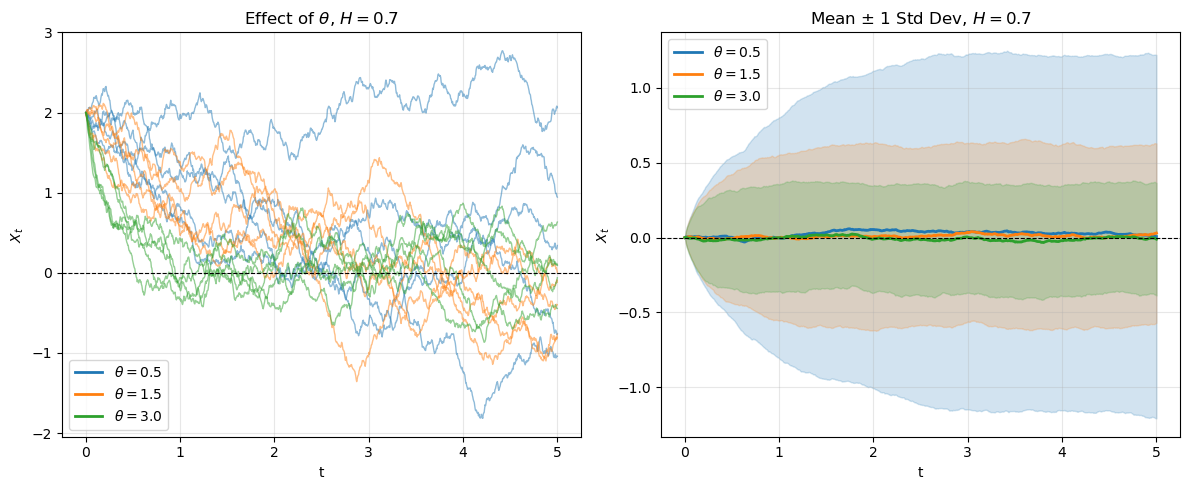

In [10]:
# Cell 7 (OPTIMIZED): Sensitivity to Theta

H = 0.7
sigma = 1.0
theta_values = [0.5, 1.5, 3.0]
n_paths = 5
n_env = 500

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['tab:blue', 'tab:orange', 'tab:green']

# Left: a few sample paths per theta
ax = axes[0]
for theta, color in zip(theta_values, colors):
    # Just 5 paths — still fast with vectorized generation
    X_few = simulate_fou_multi_independent(t, H, theta, sigma, 2.0, n_paths)
    for j in range(n_paths):
        ax.plot(t, X_few[:, j], color=color, alpha=0.5, linewidth=1.0)
    ax.plot([], [], color=color, linewidth=2, label=rf'$\theta = {theta}$')

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(rf'Effect of $\theta$, $H = {H}$')
ax.set_xlabel('t')
ax.set_ylabel(r'$X_t$')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: mean +/- std envelope (500 paths each)
ax = axes[1]
for theta, color in zip(theta_values, colors):
    X_env = simulate_fou_multi_independent(t, H, theta, sigma, 0.0, n_env)
    mean_path = np.mean(X_env, axis=1)
    std_path = np.std(X_env, axis=1)
    ax.plot(t, mean_path, color=color, linewidth=2, label=rf'$\theta = {theta}$')
    ax.fill_between(t, mean_path - std_path, mean_path + std_path, color=color, alpha=0.2)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(rf'Mean $\pm$ 1 Std Dev, $H = {H}$')
ax.set_xlabel('t')
ax.set_ylabel(r'$X_t$')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fou_theta_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()


### Effect of Volatility $\sigma$

Higher $\sigma$ increases the amplitude of fluctuations but does not change the memory structure (autocorrelation shape).


In [ ]:
# Cell 8: Sensitivity to Sigma, takes too much time

H = 0.7
theta = 1.5
sigma_values = [0.5, 1.0, 2.0]
n_paths = 5

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tab:purple', 'tab:cyan', 'tab:olive']

for sigma, color in zip(sigma_values, colors):
    for _ in range(n_paths):
        X = simulate_fou(t, H, theta, sigma, x0=0.0)
        ax.plot(t, X, color=color, alpha=0.5, linewidth=1.0)
    ax.plot([], [], color=color, linewidth=2, label=rf'$\sigma = {sigma}$')

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(rf'Effect of $\sigma$, $H = {H}$, $\theta = {theta}$')
ax.set_xlabel('t')
ax.set_ylabel(r'$X_t$')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fou_sigma_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()


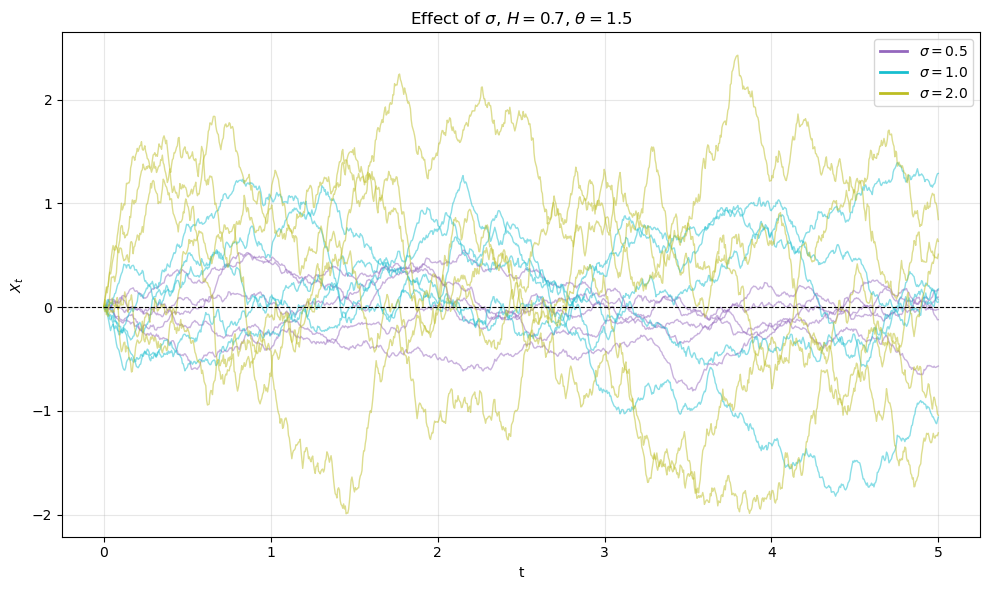

In [11]:
# Cell 8 (OPTIMIZED): Sensitivity to Sigma

H = 0.7
theta = 1.5
sigma_values = [0.5, 1.0, 2.0]
n_paths = 5

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tab:purple', 'tab:cyan', 'tab:olive']

for sigma, color in zip(sigma_values, colors):
    X_few = simulate_fou_multi_independent(t, H, theta, sigma, 0.0, n_paths)
    for j in range(n_paths):
        ax.plot(t, X_few[:, j], color=color, alpha=0.5, linewidth=1.0)
    ax.plot([], [], color=color, linewidth=2, label=rf'$\sigma = {sigma}$')

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(rf'Effect of $\sigma$, $H = {H}$, $\theta = {theta}$')
ax.set_xlabel('t')
ax.set_ylabel(r'$X_t$')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fou_sigma_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Validation: Recovering Standard OU at $H = 0.5$

For $H = 0.5$, fOU reduces to standard OU, whose exact solution is Gaussian with:
$$\mathbb{E}[X_t] = x_0 e^{-\theta t}, \quad \mathrm{Var}(X_t) = \frac{\sigma^2}{2\theta}\bigl(1 - e^{-2\theta t}\bigr)$$

We validate our Euler scheme by comparing the empirical mean and variance against these closed-form expressions.


In [ ]:
# Cell 9: Validation Against Exact OU (H = 0.5)

H = 0.5
theta = 1.0
sigma = 1.0
x0 = 3.0
n_sims_val = 2000

paths = np.array([simulate_fou(t, H, theta, sigma, x0=x0) for _ in range(n_sims_val)])
emp_mean = np.mean(paths, axis=0)
emp_var = np.var(paths, axis=0)

theo_mean = x0 * np.exp(-theta * t)
theo_var = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * t))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(t, emp_mean, 'b-', linewidth=2, label='Empirical mean')
ax.plot(t, theo_mean, 'r--', linewidth=2, label=rf'Theory: $x_0 e^{{-\theta t}}$')
ax.set_title(rf'Mean, $H = 0.5$, $x_0 = {x0}$')
ax.set_xlabel('t')
ax.set_ylabel(r'$\mathbb{E}[X_t]$')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(t, emp_var, 'b-', linewidth=2, label='Empirical variance')
ax.plot(t, theo_var, 'r--', linewidth=2, label=rf'Theory: $\frac{{\sigma^2}}{{2\theta}}(1-e^{{-2\theta t}})$')
ax.set_title(rf'Variance, $H = 0.5$')
ax.set_xlabel('t')
ax.set_ylabel(r'$\mathrm{Var}(X_t)$')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'fou_validation.png'), dpi=150, bbox_inches='tight')
plt.show()

max_err_mean = np.max(np.abs(emp_mean - theo_mean))
max_err_var = np.max(np.abs(emp_var - theo_var))
print(f"Max mean error:     {max_err_mean:.6f}")
print(f"Max variance error: {max_err_var:.6f}")


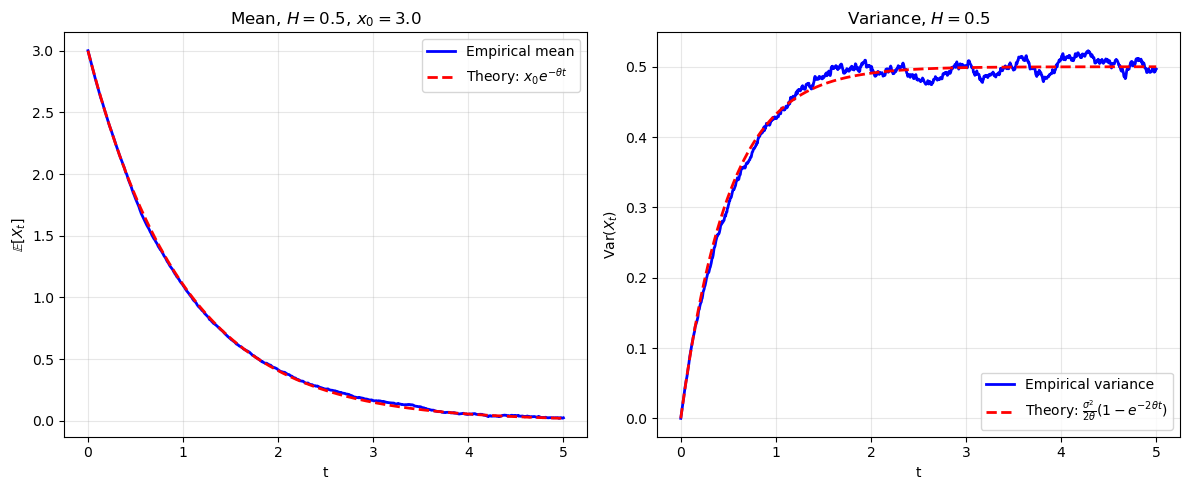

Max mean error:     0.033302
Max variance error: 0.022980


In [12]:
# Cell 9 (OPTIMIZED): Validation Against Exact OU (H = 0.5)


H = 0.5

theta = 1.0

sigma = 1.0

x0 = 3.0

n_sims_val = 2000


# ONE Cholesky for all 2000 paths

X_all = simulate_fou_multi_independent(t, H, theta, sigma, x0, n_sims_val)


emp_mean = np.mean(X_all, axis=1)

emp_var = np.var(X_all, axis=1)


theo_mean = x0 * np.exp(-theta * t)

theo_var = (sigma**2 / (2 * theta)) * (1 - np.exp(-2 * theta * t))


fig, axes = plt.subplots(1, 2, figsize=(12, 5))


ax = axes[0]

ax.plot(t, emp_mean, 'b-', linewidth=2, label='Empirical mean')

ax.plot(t, theo_mean, 'r--', linewidth=2, label=rf'Theory: $x_0 e^{{-\theta t}}$')

ax.set_title(rf'Mean, $H = 0.5$, $x_0 = {x0}$')

ax.set_xlabel('t')

ax.set_ylabel(r'$\mathbb{{E}}[X_t]$')

ax.legend()

ax.grid(True, alpha=0.3)


ax = axes[1]

ax.plot(t, emp_var, 'b-', linewidth=2, label='Empirical variance')

ax.plot(t, theo_var, 'r--', linewidth=2, label=rf'Theory: $\frac{{\sigma^2}}{{2\theta}}(1-e^{{-2\theta t}})$')

ax.set_title(rf'Variance, $H = 0.5$')

ax.set_xlabel('t')

ax.set_ylabel(r'$\mathrm{{Var}}(X_t)$')

ax.legend()

ax.grid(True, alpha=0.3)


plt.tight_layout()

plt.savefig(os.path.join(SAVE_DIR, 'fou_validation.png'), dpi=150, bbox_inches='tight')

plt.show()


max_err_mean = np.max(np.abs(emp_mean - theo_mean))

max_err_var = np.max(np.abs(emp_var - theo_var))

print(f"Max mean error:     {max_err_mean:.6f}")

print(f"Max variance error: {max_err_var:.6f}")



## 10. Summary

| Property | Standard OU ($H=0.5$) | Fractional OU ($H \neq 0.5$) |
|----------|----------------------|------------------------------|
| **Dynamics** | Mean-reverting + white noise | Mean-reverting + colored noise |
| **Memory** | None (Markovian) | Long-range ($H>0.5$) or anti-persistent ($H<0.5$) |
| **Paths** | Rough, irregular | Smoother for $H>0.5$, rougher for $H<0.5$ |
| **Stationary** | Gaussian, variance $\sigma^2/(2\theta)$ | Gaussian, variance depends on $H$ and $\theta$ |
| **Simulation** | Exact formulas available | Euler scheme with exact fBm increments |

### Key Takeaways
1. The **Euler-Maruyama scheme** with exact fBm increments is a robust simulation method.
2. For **$H > 0.5$**, the fOU process shows strong persistence — deviations from mean revert slowly.
3. The **deterministic mean-reversion** of differences ($\Delta X_t \propto e^{-\theta t}$) holds even with shared fractional noise.
4. At **$H = 0.5$**, the scheme recovers the exact theoretical mean and variance of standard OU.